# Статьи:

ACF и PACF - https://www.baeldung.com/cs/acf-pacf-plots-arma-modeling

# Загрузка библиотек

In [21]:
import pandas as pd
import numpy as np
import tqdm
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from math import sqrt
import statsmodels
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
import warnings


warnings.filterwarnings("ignore")

# Функции для анализа временных рядов

In [3]:
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

Тест Дикки-Фуллера для определения стационарности ряда. p-value < 0.05 => ряд стационарный, иначе - нестационарный.

In [4]:
def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (5, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))
        qq_ax = plt.subplot2grid(layout, (4, 0))

        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)
        sm.qqplot(y, line='s', ax=qq_ax)
        
        plt.tight_layout()
    plt.show()
    return

# Загрузка временного ряда

In [5]:
series = pd.read_csv("AirPassengers.csv", index_col=0)["#Passengers"]

series

Month
1949-01    112
1949-02    118
1949-03    132
1949-04    129
1949-05    121
          ... 
1960-08    606
1960-09    508
1960-10    461
1960-11    390
1960-12    432
Name: #Passengers, Length: 144, dtype: int64

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


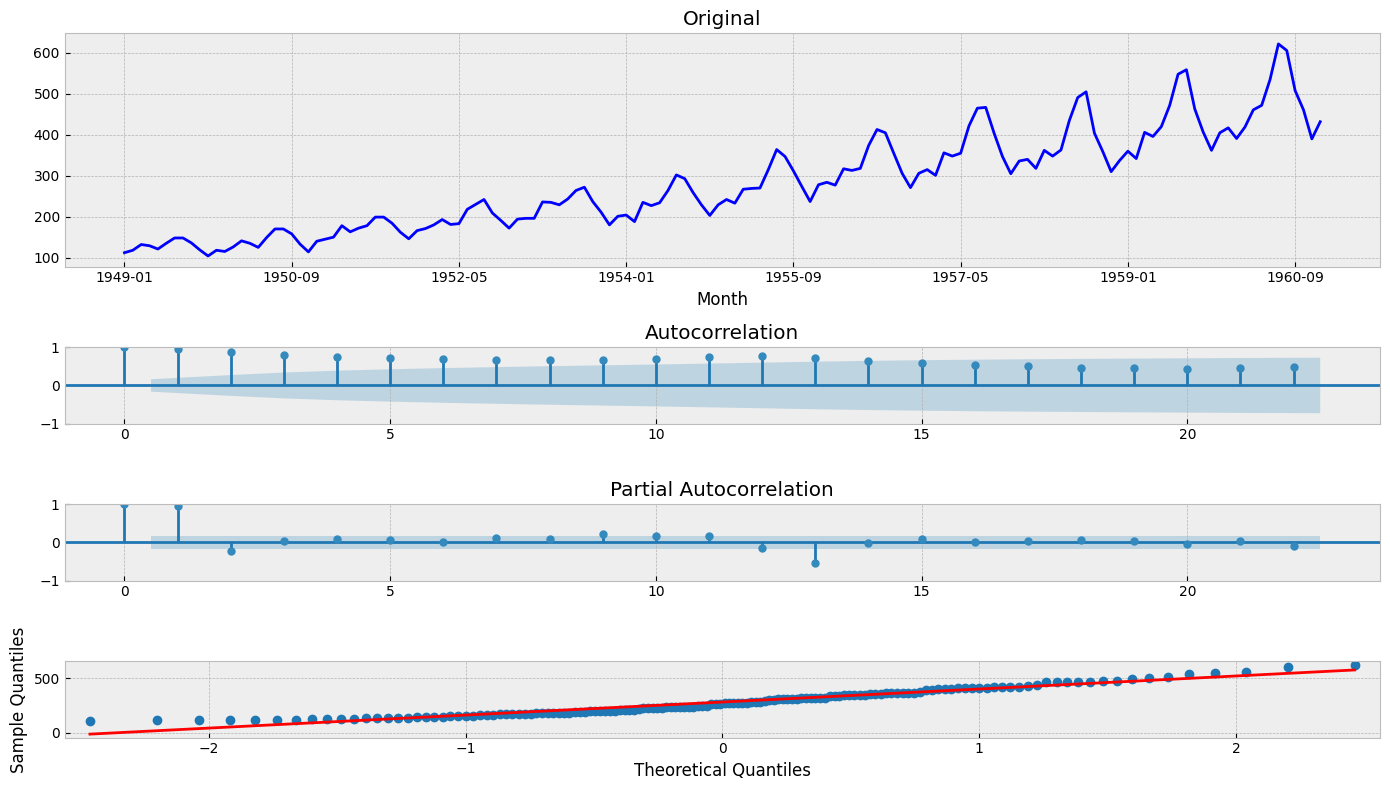

In [6]:
tsplot(series)

Для ARIMA нужно определить 3 параметра: 
* p - порядок авторегрессии (AR), то есть текущее значение t зависит от значения t-p. Определяется через график Partial Autocorrelation (PACF).
* q - порядок скользящего среднего (MA), то есть как текущее значение t зависит от ошибок значений от t-1 до t-q. Определяется через график Autocorrelation (ACF).
* d - порядок дифференцирования (кол-во раз), то есть через сколько раз временной ряд избавляется от тренда и немного сезонности.

Results of Dickey-Fuller Test:
Test Statistic                  -2.829267
p-value                          0.054213
#Lags Used                      12.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


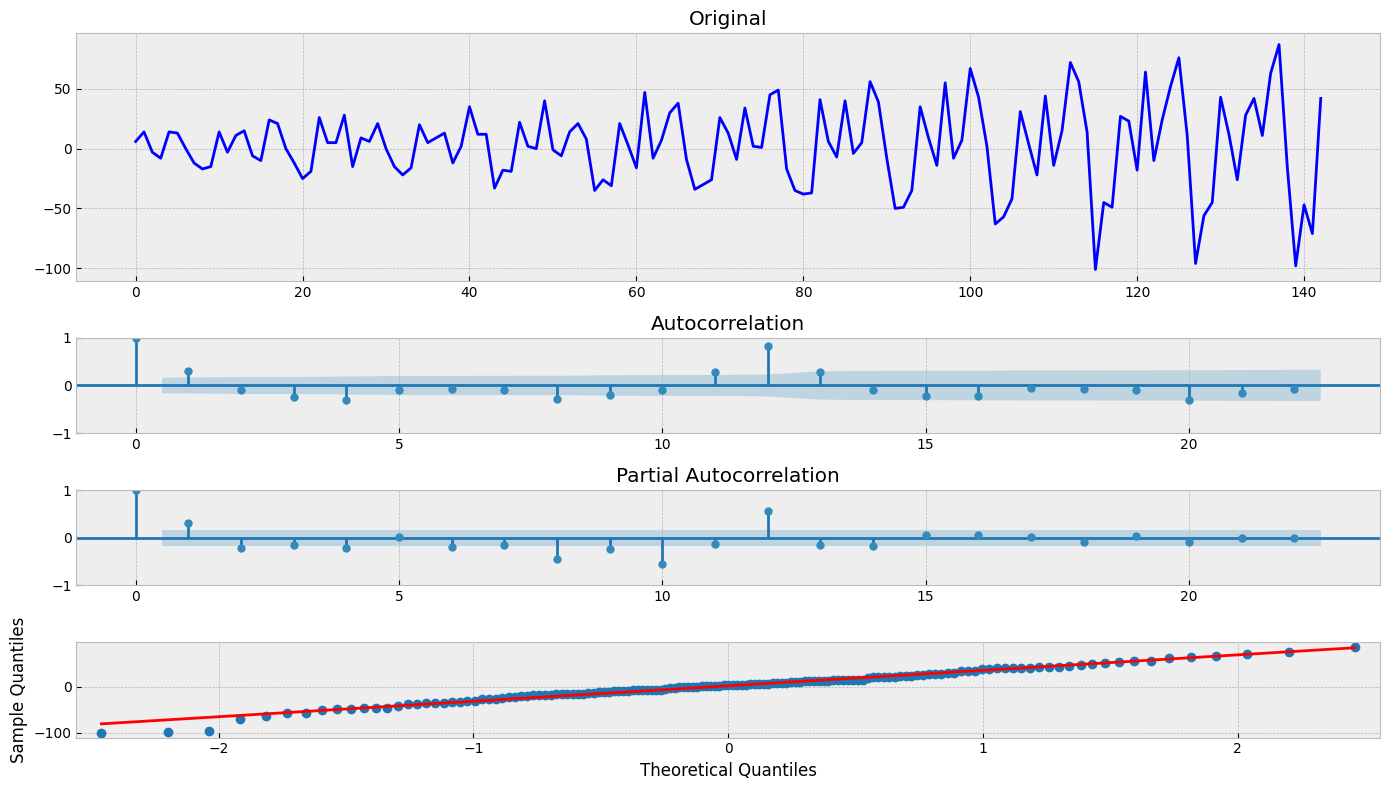

In [7]:
series_diff = np.diff(series, 1)

tsplot(series_diff)

В нашем случае, скорее всего:
* p = 12
* q = 12
* d = 1

# Модель ARIMA

In [8]:
best_aic = np.inf 
best_order = None
best_mdl = None

for p in range(13):
    for d in range(1, 2):
        for q in range(13):
            try:
                tmp_model = ARIMA(series, order=(p, d, q)).fit()

                tmp_aic = tmp_model.aic

                print(f"Order: {(p, d, q)} | AIC: {tmp_aic}")
                
                if tmp_aic < best_aic:
                    best_aic = tmp_aic
                    best_order = (p, d, q)
                    best_mdl = tmp_model
            except: continue

Order: (0, 1, 0) | AIC: 1413.9091174789412
Order: (0, 1, 1) | AIC: 1397.2575749492116
Order: (0, 1, 2) | AIC: 1397.0934620892513
Order: (0, 1, 3) | AIC: 1394.9091477944216
Order: (0, 1, 4) | AIC: 1371.8500101175805
Order: (0, 1, 5) | AIC: 1373.7413859196122
Order: (0, 1, 6) | AIC: 1358.271617162326
Order: (0, 1, 7) | AIC: 1345.1617757977845
Order: (0, 1, 8) | AIC: 1334.5190061790713
Order: (0, 1, 9) | AIC: 1330.1820852218423
Order: (0, 1, 10) | AIC: 1320.5735806601306
Order: (0, 1, 11) | AIC: 1352.8916708836841
Order: (0, 1, 12) | AIC: 1301.7335035579872
Order: (1, 1, 0) | AIC: 1401.8521274896978
Order: (1, 1, 1) | AIC: 1394.6825053251964
Order: (1, 1, 2) | AIC: 1385.4975450289621
Order: (1, 1, 3) | AIC: 1386.8922072649711
Order: (1, 1, 4) | AIC: 1373.7887745107282
Order: (1, 1, 5) | AIC: 1353.632625808535
Order: (1, 1, 6) | AIC: 1353.9091559797255
Order: (1, 1, 7) | AIC: 1331.8642557554049
Order: (1, 1, 8) | AIC: 1337.65361345813
Order: (1, 1, 9) | AIC: 1337.6691818916886
Order: (1, 1

Best Order: (12, 1, 3) | AIC: 1143.59185018251
Results of Dickey-Fuller Test:
Test Statistic                -1.536012e+01
p-value                        3.622040e-28
#Lags Used                     0.000000e+00
Number of Observations Used    1.430000e+02
Critical Value (1%)           -3.476927e+00
Critical Value (5%)           -2.881973e+00
Critical Value (10%)          -2.577665e+00
dtype: float64


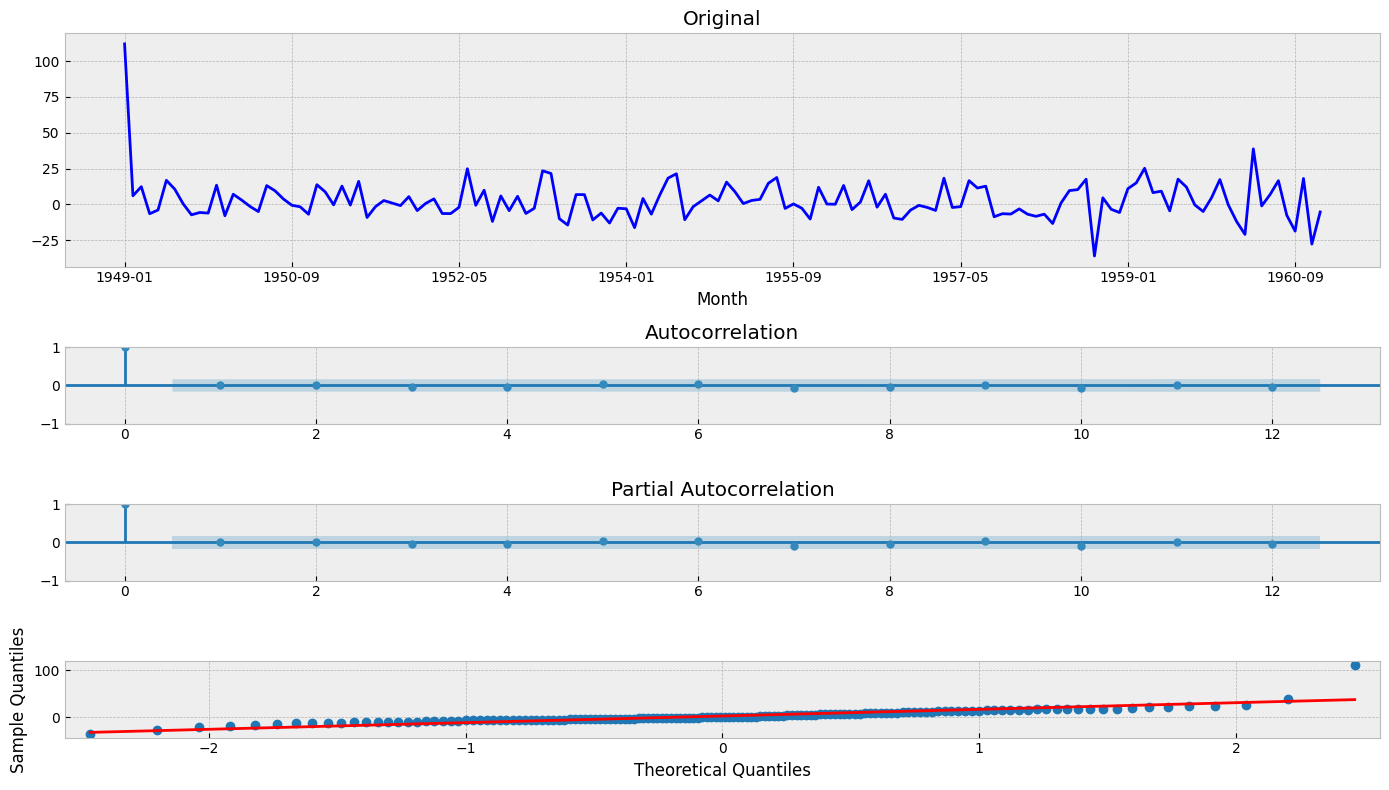

In [12]:
print(f"Best Order: {best_order} | AIC: {best_aic}")

tsplot(best_mdl.resid, lags=12)

Модель отлично справилась, так как остатки модели (белый шум) нестационарный.

# Подготовка данных для предсказания

In [13]:
def create_lag_features(series, lags):
    df = pd.DataFrame(series)
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = series.shift(lag)
    df.dropna(inplace=True)
    return df

# Получение остатков
residuals = best_mdl.resid

df_lags = create_lag_features(residuals, lags=12)

df_lags

,0,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12
Month,,,,,,,,,,,,,
1950-01,-7.972398,13.342945,-6.130626,-5.721919,-7.329486,0.404792,10.596812,16.756899,-3.986087,-6.575322,12.316913,5.953956,112.000000
1950-02,7.007707,-7.972398,13.342945,-6.130626,-5.721919,-7.329486,0.404792,10.596812,16.756899,-3.986087,-6.575322,12.316913,5.953956
1950-03,2.967431,7.007707,-7.972398,13.342945,-6.130626,-5.721919,-7.329486,0.404792,10.596812,16.756899,-3.986087,-6.575322,12.316913
1950-04,-1.479251,2.967431,7.007707,-7.972398,13.342945,-6.130626,-5.721919,-7.329486,0.404792,10.596812,16.756899,-3.986087,-6.575322
1950-05,-5.084839,-1.479251,2.967431,7.007707,-7.972398,13.342945,-6.130626,-5.721919,-7.329486,0.404792,10.596812,16.756899,-3.986087
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960-08,-7.636681,16.500108,6.794798,-1.131616,38.728986,-21.009178,-12.015727,-0.307893,17.284504,4.559769,-5.016390,-0.385431,12.022408
1960-09,-18.704840,-7.636681,16.500108,6.794798,-1.131616,38.728986,-21.009178,-12.015727,-0.307893,17.284504,4.559769,-5.016390,-0.385431
1960-10,18.038139,-18.704840,-7.636681,16.500108,6.794798,-1.131616,38.728986,-21.009178,-12.015727,-0.307893,17.284504,4.559769,-5.016390


## Разделение на X и Y

In [14]:
train_size = int(len(df_lags) * 0.8)

train, test = df_lags.iloc[:train_size], df_lags.iloc[train_size:]

X_train, y_train = train.drop(columns=0), train[0]
X_test, y_test = test.drop(columns=0), test[0]

In [19]:
rfr = RandomForestRegressor(random_state=42)

rfr.fit(X_train, y_train)

residuals_pred = rfr.predict(X_test)

rmse = root_mean_squared_error(y_test, residuals_pred)

print("RMSE: ", rmse)

RMSE:  15.212621366776881


In [20]:
param_grid = [
    {'criterion':['squared_error','friedman_mse'], 'max_depth':[None,2,5,10,20,50], 'max_leaf_nodes':[None,2,5,10,20,50]}
]

rfr = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rfr, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END criterion=squared_error, max_depth=None, max_leaf_nodes=None; total time=   0.1s
[CV] END criterion=squared_error, max_depth=None, max_leaf_nodes=None; total time=   0.0s
[CV] END criterion=squared_error, max_depth=None, max_leaf_nodes=None; total time=   0.1s
[CV] END criterion=squared_error, max_depth=None, max_leaf_nodes=None; total time=   0.1s
[CV] END criterion=squared_error, max_depth=None, max_leaf_nodes=None; total time=   0.1s
[CV] END criterion=squared_error, max_depth=None, max_leaf_nodes=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=None, max_leaf_nodes=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=None, max_leaf_nodes=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=None, max_leaf_nodes=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=None, max_leaf_nodes=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=None, max

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'criterion': ['squared_error', 'friedman_mse'],
                          'max_depth': [None, 2, 5, 10, 20, 50],
                          'max_leaf_nodes': [None, 2, 5, 10, 20, 50]}],
             scoring='neg_mean_squared_error', verbose=2)

In [22]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)

residuals_pred = best_model.predict(X_test)

rmse = root_mean_squared_error(y_test, residuals_pred)

print("RMSE: ", rmse)

RMSE:  14.846342334328149


# Предсказание на будущее

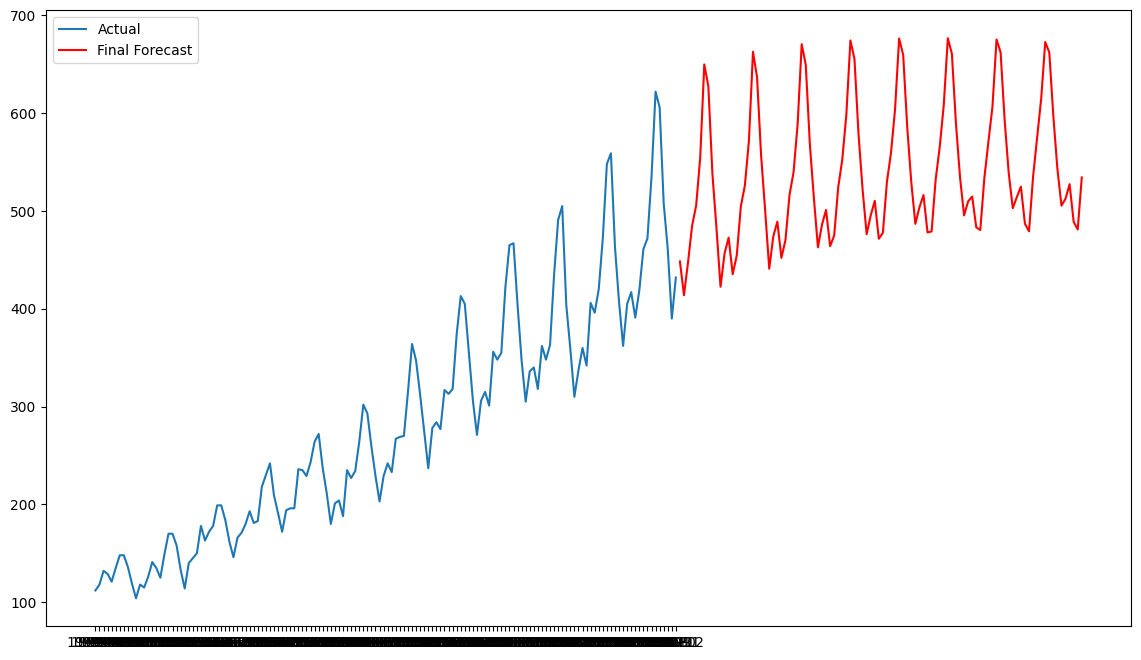

In [26]:
forecast_steps = 100
forecast = best_mdl.forecast(steps=forecast_steps)
forecast_index = np.arange(len(series), len(series) + forecast_steps)

# Прогнозирование будущих остатков
future_residuals = best_model.predict(df_lags.drop(columns=0).iloc[-forecast_steps:].values)

# Финальное прогнозирование: прогноз ARIMA + прогноз остатков
final_forecast = forecast + future_residuals

# Визуализация результатов
plt.figure(figsize=(14, 8))
plt.plot(series, label='Actual')
plt.plot(forecast_index, final_forecast, label='Final Forecast', color='red')
plt.legend()
plt.show()

# Вывод: 
Были применены 2 модели ARIMA и RandomForestRegressor. ARIMA - предсказание следующих значений. RandomForestRegressor - предсказание остатков (ошибок, которые совершает ARIMA) для улучшения модели.